# Étape 4 — Appliquez une méthode semi-supervisée

**Projet 10** — Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Auteur :** David MEDRAGH — Mai 2026

---

## Objectif

Dans cette étape, j'entraîne un CNN (ResNet50 fine-tuné) en suivant deux approches :
- **Modèle A — Supervisé pur** : entraîné uniquement sur les 64 images fortement labellisées
- **Modèle B — Semi-supervisé** : pré-entraîné sur les 1 406 pseudo-labels (étape 3), puis fine-tuné sur les 64 images fortes

Je compare ensuite les performances des deux approches sur un jeu test de 20 images fortes jamais vues.

## Protocole anti-fuite

Pour garantir la validité expérimentale de la comparaison :
1. Le split train/val/test est fait **avant** tout re-clustering
2. K-Means est re-calculé **sans** les 20 images test
3. Le mapping cluster → classe utilise **uniquement** les 64 images train
4. Le jeu test est touché **une seule fois** par modèle, à l'évaluation finale

## Justification métier

Dans un contexte de détection de tumeurs cérébrales (CurelyticsIA), l'erreur la plus grave est le **Faux Négatif** : dire à un patient porteur d'une tumeur qu'il est sain. La métrique reine est donc le **Recall sur la classe cancer**, quitte à sacrifier un peu de précision. Le F1-score (macro) sert de métrique d'arbitrage globale.

## Definition of done

- [ ] Split stratifié train/val/test (64/16/20) sur le jeu fort
- [ ] K-Means re-calculé sans les 20 images test
- [ ] Mapping cluster → classe refait sur le train uniquement
- [ ] Weak labels re-générés proprement
- [ ] Modèle A entraîné sur 64, val 16, évalué sur 20
- [ ] Modèle B (weak → strong) entraîné et évalué sur le même test
- [ ] Même architecture, mêmes transforms, même protocole pour A et B
- [ ] F1, accuracy, recall cancer, matrice de confusion
- [ ] Comparaison tabulaire + visuelle
- [ ] Recommandations passage à l'échelle
- [ ] `random_state=42` partout

## Stack technique de l'etape 4

Le visuel ci-dessous synthétise les outils mobilisés pour le split anti-fuite, la préparation des données, le fine-tuning de ResNet50 et l'évaluation comparative des modèles.

![Stack technique generale de l etape 4](doc/png/projet10_etape4_stack_technique_generale.png)


## Diagrammes UML de l'etape 4

Les diagrammes ci-dessous completent le notebook en explicitant le workflow global, la logique anti-fuite, l'architecture CNN et la comparaison finale entre les deux protocoles d'apprentissage.

### Architecture technique CNN semi-supervisee

![Architecture technique CNN semi-supervisee](doc/uml/png/etape4_diagramme_composants_architecture_cnn_semi_supervise.png)

### Workflow global de l'apprentissage semi-supervise

![Workflow global de l'apprentissage semi-supervise](doc/uml/png/etape4_diagramme_activite_workflow_apprentissage_semi_supervise.png)

### Split et logique anti-fuite

![Split et logique anti-fuite](doc/uml/png/etape4_diagramme_activite_split_et_anti_fuite.png)

### Entrainement semi-supervise

![Entrainement semi-supervise](doc/uml/png/etape4_diagramme_activite_entrainement_semi_supervise.png)

### Comparaison supervise pur vs semi-supervise

![Comparaison supervise pur vs semi-supervise](doc/uml/png/etape4_diagramme_activite_comparaison_supervise_vs_semi_supervise.png)


## Imports et versions

Je charge les bibliothèques nécessaires :
- **torch / torchvision** : ResNet50, Dataset, DataLoader, entraînement CNN (recommandé par l'école)
- **scikit-learn** : train_test_split, StandardScaler, KMeans, métriques (recommandé par l'école)
- **seaborn / matplotlib** : visualisation des résultats
- **numpy / pandas** : manipulation des données

In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# --- Bibliothèques standard ---
from pathlib import Path
import copy
import time

# --- Bibliothèques scientifiques ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Deep Learning ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

# --- Barres de progression ---
from tqdm.notebook import tqdm

# --- Constantes ---
RANDOM_STATE = 42
NUM_CLASSES = 2
BATCH_SIZE = 16
NUM_EPOCHS_WEAK = 10
NUM_EPOCHS_STRONG = 30
LEARNING_RATE = 1e-4
PATIENCE = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['cancer', 'normal']
LABEL_MAP = {'cancer': 0, 'normal': 1}

# Reproductibilité
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Chargement des données
FEATURES_DIR = Path('data/features')
features = np.load(FEATURES_DIR / 'features.npy')
metadata = pd.read_csv(FEATURES_DIR / 'metadata.csv')

print(f'Device           : {DEVICE}')
print(f'Features         : {features.shape}')
print(f'Métadonnées      : {len(metadata)} lignes')
print(f'Labellisées      : {metadata["is_labeled"].sum()}')
print(f'Sans label       : {(~metadata["is_labeled"]).sum()}')

Device           : cpu
Features         : (1506, 2048)
Métadonnées      : 1506 lignes
Labellisées      : 100
Sans label       : 1406


## Split train / val / test

Je sépare les 100 images fortement labellisées en trois sous-ensembles :
- **Train (64)** : entraînement des modèles A et B
- **Val (16)** : early stopping pendant l'entraînement
- **Test (20)** : évaluation finale unique, jamais vu pendant l'entraînement

Les deux splits sont **stratifiés** pour maintenir l'équilibre cancer/normal dans chaque sous-ensemble.

### Pourquoi `train_test_split` et pas `random_split` ?

Avec seulement 80 images, un `random_split` de PyTorch ne garantit pas la stratification. Sur des effectifs aussi faibles, un déséquilibre accidentel (ex. 30 cancer / 34 normal au lieu de 32/32) biaiserait les résultats.

In [2]:
# Séparer labellisées et non labellisées
mask_labeled = metadata['is_labeled'] == True
idx_labeled = metadata[mask_labeled].index.values
idx_unlabeled = metadata[~mask_labeled].index.values

# Split 1 : 100 → 80 train / 20 test (stratifié)
idx_train_80, idx_test = train_test_split(
    idx_labeled, test_size=0.2,
    stratify=metadata.loc[idx_labeled, 'label_id'].astype(int),
    random_state=RANDOM_STATE
)

# Split 2 : 80 → 64 train / 16 val (stratifié)
idx_train_64, idx_val = train_test_split(
    idx_train_80, test_size=0.2,
    stratify=metadata.loc[idx_train_80, 'label_id'].astype(int),
    random_state=RANDOM_STATE
)

# Vérification de l'équilibre
print('Split stratifié des 100 images fortement labellisées :')
print('=' * 55)
for name, idx in [('Train (64)', idx_train_64), ('Val (16)', idx_val), ('Test (20)', idx_test)]:
    labels = metadata.loc[idx, 'label_name'].value_counts()
    print(f'  {name:15s} : {len(idx)} images — {dict(labels)}')
print(f'  {"Unlabeled":15s} : {len(idx_unlabeled)} images')

# Vérifier qu'aucun indice ne fuit entre les splits
assert len(set(idx_train_64) & set(idx_val)) == 0, 'Fuite train/val !'
assert len(set(idx_train_64) & set(idx_test)) == 0, 'Fuite train/test !'
assert len(set(idx_val) & set(idx_test)) == 0, 'Fuite val/test !'
print('\n✓ Aucune fuite détectée entre les splits.')

Split stratifié des 100 images fortement labellisées :
  Train (64)      : 64 images — {'normal': np.int64(32), 'cancer': np.int64(32)}
  Val (16)        : 16 images — {'cancer': np.int64(8), 'normal': np.int64(8)}
  Test (20)       : 20 images — {'normal': np.int64(10), 'cancer': np.int64(10)}
  Unlabeled       : 1406 images

✓ Aucune fuite détectée entre les splits.


## Re-clustering sans fuite

À l'étape 3, K-Means avait été calculé sur les **1 506 images** (dont les 20 futures images test). Le mapping cluster → classe utilisait les **100 labels forts** (dont les 20 futures images test). Ces deux points constituent une fuite d'information.

Je corrige maintenant :
1. **Re-fit K-Means** sur 1 486 images (80 train forts + 1 406 non labellisées, **sans** les 20 test)
2. **Re-standardisation** sur ces 1 486 images
3. **Re-mapping** cluster → classe par vote majoritaire sur les **64 images train uniquement**
4. **Re-génération** des weak labels pour les 1 406 images non labellisées

In [3]:
# 1. Créer le sous-ensemble de features SANS les 20 images test
idx_no_test = np.concatenate([idx_train_80, idx_unlabeled])  # 80 + 1406 = 1486
features_no_test = features[idx_no_test]
print(f'Features sans test : {features_no_test.shape}')

# 2. Re-standardiser sur ces 1 486 images
scaler_clean = StandardScaler()
features_no_test_scaled = scaler_clean.fit_transform(features_no_test)

# 3. Re-fit K-Means (k=2) sur les 1 486 images
kmeans_clean = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels_clean = kmeans_clean.fit_predict(features_no_test_scaled)

# 4. Mapper indices globaux → clusters
cluster_map = dict(zip(idx_no_test, kmeans_labels_clean))

# 5. Crosstab sur les 64 images train UNIQUEMENT
df_train_for_mapping = metadata.loc[idx_train_64].copy()
df_train_for_mapping['cluster'] = df_train_for_mapping.index.map(cluster_map)
cross_tab = pd.crosstab(df_train_for_mapping['cluster'], df_train_for_mapping['label_name'])
print(f'\nTableau croisé (cluster × label) sur les 64 images train :')
print(cross_tab)

# 6. Vote majoritaire → mapping cluster → classe
cluster_to_class = {c: cross_tab.loc[c].idxmax() for c in cross_tab.index}
print(f'\nMapping cluster → classe :')
for k, v in cluster_to_class.items():
    print(f'  Cluster {k} → {v}')

# 7. Appliquer aux 1 406 images non labellisées
df_unlabeled = metadata.loc[idx_unlabeled].copy()
df_unlabeled['cluster'] = df_unlabeled.index.map(cluster_map)
df_unlabeled['weak_label'] = df_unlabeled['cluster'].map(cluster_to_class)
df_unlabeled['weak_label_id'] = df_unlabeled['weak_label'].map(LABEL_MAP).astype(int)

print(f'\nDistribution des weak labels propres :')
print(df_unlabeled['weak_label'].value_counts())

Features sans test : (1486, 2048)

Tableau croisé (cluster × label) sur les 64 images train :
label_name  cancer  normal
cluster                   
0               15       1
1               17      31

Mapping cluster → classe :
  Cluster 0 → cancer
  Cluster 1 → normal

Distribution des weak labels propres :
weak_label
normal    900
cancer    506
Name: count, dtype: int64


In [4]:
# Comparaison avec l'ancien mapping (étape 3)
old_weak = pd.read_csv(FEATURES_DIR / 'metadata_weak_labels.csv')
merged = df_unlabeled[['filename', 'weak_label']].merge(
    old_weak[['filename', 'weak_label']], on='filename', suffixes=('_new', '_old')
)
changes = (merged['weak_label_new'] != merged['weak_label_old']).sum()
print(f'Labels changés entre ancien et nouveau mapping : {changes} / {len(merged)} ({changes/len(merged):.1%})')

# Résumé des jeux de données
print(f'\n{"═" * 55}')
print(f'Résumé des jeux de données pour l\'étape 4')
print(f'{"═" * 55}')
print(f'  Train (fort)   : {len(idx_train_64)} images — labels radiologues')
print(f'  Val (fort)     : {len(idx_val)} images — labels radiologues')
print(f'  Test (fort)    : {len(idx_test)} images — labels radiologues (jamais vu)')
print(f'  Weak (pseudo)  : {len(df_unlabeled)} images — pseudo-labels K-Means propres')

Labels changés entre ancien et nouveau mapping : 52 / 1406 (3.7%)

═══════════════════════════════════════════════════════
Résumé des jeux de données pour l'étape 4
═══════════════════════════════════════════════════════
  Train (fort)   : 64 images — labels radiologues
  Val (fort)     : 16 images — labels radiologues
  Test (fort)    : 20 images — labels radiologues (jamais vu)
  Weak (pseudo)  : 1406 images — pseudo-labels K-Means propres


## Dataset et DataLoaders PyTorch

Je crée un Dataset custom qui :
1. Charge chaque image depuis son chemin
2. Applique le preprocessing officiel ResNet50 (`weights.transforms()`)
3. Retourne le tenseur et le label entier

Pour le jeu faible, j'utilise un `WeightedRandomSampler` pour compenser le léger déséquilibre des pseudo-labels.

In [5]:
class BrainMRIDataset(Dataset):
    """Dataset PyTorch pour les IRM cérébrales."""

    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Charger l'image et appliquer le preprocessing ResNet50
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [6]:
# Transform officiel ResNet50 (identique pour train, val, test)
weights = ResNet50_Weights.DEFAULT
transform = weights.transforms()

# --- Datasets ---
ds_train = BrainMRIDataset(
    paths=metadata.loc[idx_train_64, 'path'].values,
    labels=metadata.loc[idx_train_64, 'label_id'].astype(int).values,
    transform=transform
)
ds_val = BrainMRIDataset(
    paths=metadata.loc[idx_val, 'path'].values,
    labels=metadata.loc[idx_val, 'label_id'].astype(int).values,
    transform=transform
)
ds_test = BrainMRIDataset(
    paths=metadata.loc[idx_test, 'path'].values,
    labels=metadata.loc[idx_test, 'label_id'].astype(int).values,
    transform=transform
)
ds_weak = BrainMRIDataset(
    paths=df_unlabeled['path'].values,
    labels=df_unlabeled['weak_label_id'].values,
    transform=transform
)

# --- WeightedRandomSampler pour le jeu faible ---
weak_labels_array = df_unlabeled['weak_label_id'].values
class_counts = np.bincount(weak_labels_array)
class_weights = 1.0 / class_counts
sample_weights = class_weights[weak_labels_array]
sampler_weak = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(ds_weak), replacement=True
)

# --- DataLoaders ---
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
dl_weak = DataLoader(ds_weak, batch_size=BATCH_SIZE, sampler=sampler_weak)

print(f'dl_train : {len(ds_train):5d} images, {len(dl_train)} batches')
print(f'dl_val   : {len(ds_val):5d} images, {len(dl_val)} batches')
print(f'dl_test  : {len(ds_test):5d} images, {len(dl_test)} batches')
print(f'dl_weak  : {len(ds_weak):5d} images, {len(dl_weak)} batches')

dl_train :    64 images, 4 batches
dl_val   :    16 images, 1 batches
dl_test  :    20 images, 2 batches
dl_weak  :  1406 images, 88 batches


In [7]:
# Vérification : un batch de chaque loader
for name, dl in [('train', dl_train), ('val', dl_val), ('test', dl_test), ('weak', dl_weak)]:
    imgs, labels = next(iter(dl))
    print(f'{name:6s} — shape: {tuple(imgs.shape)}, labels: {labels.tolist()}')

train  — shape: (16, 3, 224, 224), labels: [1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0]
val    — shape: (16, 3, 224, 224), labels: [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1]
test   — shape: (16, 3, 224, 224), labels: [1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
weak   — shape: (16, 3, 224, 224), labels: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1]


## Architecture CNN — Fine-tuning ResNet50

Je fine-tune ResNet50 (pré-entraîné ImageNet) en dégelant :
- **`layer4`** : les derniers blocs convolutifs, qui captent les features de haut niveau
- **`fc`** : la couche de classification, remplacée par `Linear(2048, 2)`

Les couches `layer1` à `layer3` restent gelées (features ImageNet de bas/moyen niveau, transférables).

**Choix de ResNet50** : cohérence avec l'étape 2 (même modèle de bout en bout). En production, ResNet18 serait plus pragmatique (moins de paramètres, entraînement plus rapide).

**Protocole identique** : les modèles A et B utilisent exactement la même architecture, les mêmes transforms et le même optimiseur. Seules les données d'entraînement diffèrent.

In [8]:
def create_model(verbose=True):
    """Crée un ResNet50 fine-tunable : layer4 + fc dégelés."""
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    # Geler toutes les couches
    for param in model.parameters():
        param.requires_grad = False

    # Dégeler layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Remplacer la couche de classification
    model.fc = nn.Linear(2048, NUM_CLASSES)

    if verbose:
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Paramètres totaux       : {total:>12,}')
        print(f'Paramètres entraînables : {trainable:>12,} ({trainable/total:.1%})')
        print(f'Paramètres gelés        : {total - trainable:>12,} ({(total-trainable)/total:.1%})')

    return model.to(DEVICE)

# Test
_ = create_model()

Paramètres totaux       :   23,512,130
Paramètres entraînables :   14,968,834 (63.7%)
Paramètres gelés        :    8,543,296 (36.3%)


In [9]:
def train_one_epoch(model, dl, criterion, optimizer, desc='Train'):
    """Entraîne le modèle sur un epoch avec barre de progression."""
    model.train()
    total_loss = 0.0
    n_batches = 0

    pbar = tqdm(dl, desc=desc, leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f'{total_loss/n_batches:.4f}')

    return total_loss / n_batches


def evaluate(model, dl, desc='Eval'):
    """Évalue le modèle avec barre de progression."""
    model.eval()
    all_true, all_pred = [], []
    total_loss = 0.0
    n_batches = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        pbar = tqdm(dl, desc=desc, leave=False)
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            total_loss += loss.item()
            n_batches += 1

    return np.array(all_true), np.array(all_pred), total_loss / n_batches

print('✓ Fonctions train_one_epoch et evaluate définies (avec barres de progression).')

✓ Fonctions train_one_epoch et evaluate définies (avec barres de progression).


In [10]:
def full_training(model, dl_train, num_epochs, lr, dl_val=None, patience=None, phase_name=''):
    """
    Entraîne le modèle avec optionnellement early stopping.
    Si dl_val est None : entraînement sans early stopping (pour le weak).
    Affiche une barre de progression globale sur les époques.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = copy.deepcopy(model.state_dict())

    epoch_pbar = tqdm(range(num_epochs), desc=phase_name or 'Entraînement', unit='epoch')
    for epoch in epoch_pbar:
        # Entraînement
        train_loss = train_one_epoch(model, dl_train, criterion, optimizer,
                                     desc=f'Epoch {epoch+1}/{num_epochs}')
        history['train_loss'].append(train_loss)

        # Validation (si disponible)
        if dl_val is not None:
            _, _, val_loss = evaluate(model, dl_val, desc='Val')
            history['val_loss'].append(val_loss)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1

            star = ' ★' if patience_counter == 0 else ''
            epoch_pbar.set_postfix(
                train=f'{train_loss:.4f}', val=f'{val_loss:.4f}',
                best=f'{best_val_loss:.4f}', patience=f'{patience_counter}/{patience or "-"}'
            )

            if patience and patience_counter >= patience:
                epoch_pbar.set_description(f'{phase_name} (early stop epoch {epoch+1})')
                break
        else:
            # Pas de validation
            best_state = copy.deepcopy(model.state_dict())
            epoch_pbar.set_postfix(train=f'{train_loss:.4f}')

    # Restaurer le meilleur modèle
    model.load_state_dict(best_state)
    return model, history

print('✓ Fonction full_training définie (avec barres de progression).')

✓ Fonction full_training définie (avec barres de progression).


## Modèle A — Supervisé pur

J'entraîne ResNet50 fine-tuné **uniquement sur les 64 images fortement labellisées**. La validation se fait sur les 16 images val. L'early stopping (patience=5) arrête l'entraînement si la val loss ne diminue plus.

════════════════════════════════════════════════════════════
MODÈLE A — Supervisé pur (64 images fortes)
════════════════════════════════════════════════════════════
Paramètres totaux       :   23,512,130
Paramètres entraînables :   14,968,834 (63.7%)
Paramètres gelés        :    8,543,296 (36.3%)


Modèle A:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 8/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]


Temps modèle A : 56s


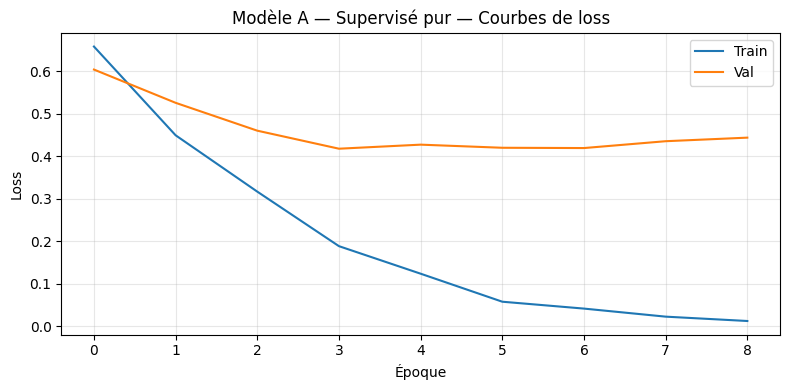

In [11]:
print('═' * 60)
print('MODÈLE A — Supervisé pur (64 images fortes)')
print('═' * 60)

model_A = create_model()
t0 = time.time()
model_A, history_A = full_training(
    model_A, dl_train, NUM_EPOCHS_STRONG, LEARNING_RATE,
    dl_val=dl_val, patience=PATIENCE, phase_name='Modèle A'
)
t1 = time.time()
print(f'\nTemps modèle A : {t1 - t0:.0f}s')

# Courbes de loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_A['train_loss'], label='Train')
ax.plot(history_A['val_loss'], label='Val')
ax.set_xlabel('Époque')
ax.set_ylabel('Loss')
ax.set_title('Modèle A — Supervisé pur — Courbes de loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
def compute_metrics(y_true, y_pred, model_name):
    """Calcule et affiche les métriques. Retourne un dict."""
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    prec = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n{"═" * 50}')
    print(f'{model_name}')
    print(f'{"═" * 50}')
    print(f'F1 (macro)        : {f1:.4f}')
    print(f'Accuracy          : {acc:.4f}')
    print(f'Recall cancer     : {rec:.4f}')
    print(f'Precision cancer  : {prec:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}')

    return {'model': model_name, 'f1': f1, 'accuracy': acc,
            'recall_cancer': rec, 'precision_cancer': prec, 'cm': cm}


# Évaluation finale — Modèle A sur le test (20 images)
y_true_A, y_pred_A, _ = evaluate(model_A, dl_test)
results_A = compute_metrics(y_true_A, y_pred_A, 'Modèle A — Supervisé pur')

Eval:   0%|          | 0/2 [00:00<?, ?it/s]


══════════════════════════════════════════════════
Modèle A — Supervisé pur
══════════════════════════════════════════════════
F1 (macro)        : 0.7917
Accuracy          : 0.8000
Recall cancer     : 0.6000
Precision cancer  : 1.0000

              precision    recall  f1-score   support

      cancer       1.00      0.60      0.75        10
      normal       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



## Modèle B — Semi-supervisé

### Phase 1 : Pré-entraînement sur 1 406 weak labels

J'entraîne le même ResNet50 fine-tuné sur les pseudo-labels produits par K-Means (corrigés sans fuite). L'objectif n'est pas la performance mais de donner au modèle une **initialisation orientée** vers la distinction cancer/normal.

Il n'y a **pas d'early stopping** ici car je n'ai pas de validation fiable pour les pseudo-labels. Le nombre d'époques est fixé à 10.

════════════════════════════════════════════════════════════
MODÈLE B — Phase 1 : Pré-entraînement sur 1 406 weak labels
════════════════════════════════════════════════════════════
Paramètres totaux       :   23,512,130
Paramètres entraînables :   14,968,834 (63.7%)
Paramètres gelés        :    8,543,296 (36.3%)


B phase 1 (weak):   0%|          | 0/10 [00:00<?, ?epoch/s]

Epoch 1/10:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/88 [00:00<?, ?it/s]

...

Epoch 7/10:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/88 [00:00<?, ?it/s]


Temps phase 1 : 1157s


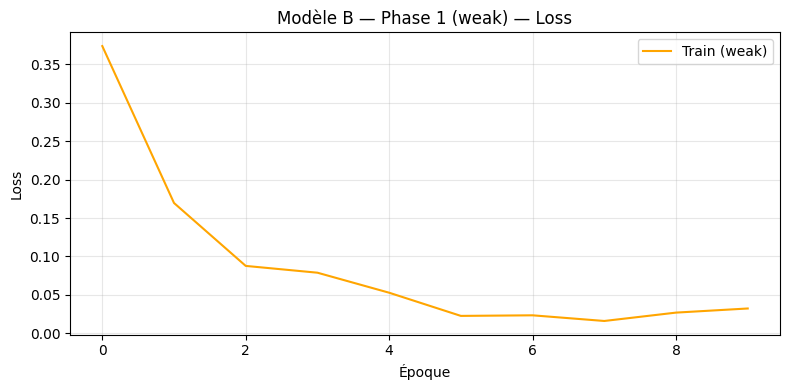

In [13]:
print('═' * 60)
print('MODÈLE B — Phase 1 : Pré-entraînement sur 1 406 weak labels')
print('═' * 60)

model_B = create_model()
t0 = time.time()
model_B, history_B_weak = full_training(
    model_B, dl_weak, NUM_EPOCHS_WEAK, LEARNING_RATE,
    phase_name='B phase 1 (weak)'
    # Pas de dl_val, pas d'early stopping
)
t1 = time.time()
print(f'\nTemps phase 1 : {t1 - t0:.0f}s')

# Sauvegarder le checkpoint post-weak (pour évaluation bonus sur val)
state_B_weak = copy.deepcopy(model_B.state_dict())

# Courbe de loss (train uniquement)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_B_weak['train_loss'], label='Train (weak)', color='orange')
ax.set_xlabel('Époque')
ax.set_ylabel('Loss')
ax.set_title('Modèle B — Phase 1 (weak) — Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Phase 2 : Fine-tuning sur 64 images fortes

Je reprends le modèle pré-entraîné sur les weak labels et je poursuis l'entraînement sur les 64 images fortement labellisées. Le protocole est **identique** à celui du modèle A : même split (64 train / 16 val), même early stopping (patience=5), même learning rate.

════════════════════════════════════════════════════════════
MODÈLE B — Phase 2 : Fine-tuning sur 64 images fortes
════════════════════════════════════════════════════════════


B phase 2 (strong):   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 13/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 14/30:   0%|          | 0/4 [00:00<?, ?it/s]

Val:   0%|          | 0/1 [00:00<?, ?it/s]


Temps phase 2 : 84s


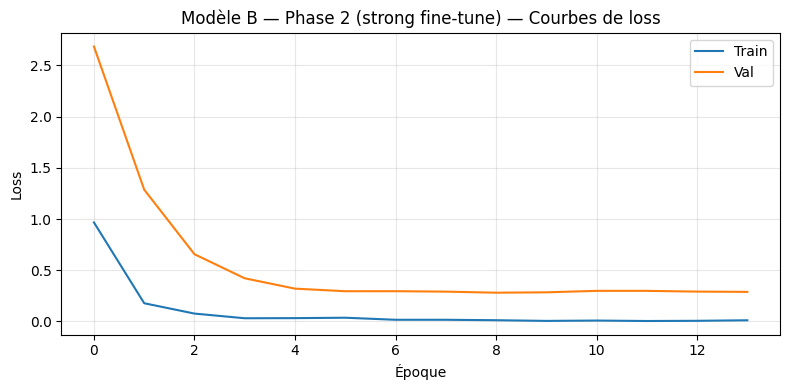

In [14]:
print('═' * 60)
print('MODÈLE B — Phase 2 : Fine-tuning sur 64 images fortes')
print('═' * 60)

t0 = time.time()
model_B, history_B_strong = full_training(
    model_B, dl_train, NUM_EPOCHS_STRONG, LEARNING_RATE,
    dl_val=dl_val, patience=PATIENCE, phase_name='B phase 2 (strong)'
)
t1 = time.time()
print(f'\nTemps phase 2 : {t1 - t0:.0f}s')

# Courbes de loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_B_strong['train_loss'], label='Train')
ax.plot(history_B_strong['val_loss'], label='Val')
ax.set_xlabel('Époque')
ax.set_ylabel('Loss')
ax.set_title('Modèle B — Phase 2 (strong fine-tune) — Courbes de loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Évaluation finale — Modèle B sur le test (20 images)
y_true_B, y_pred_B, _ = evaluate(model_B, dl_test)
results_B = compute_metrics(y_true_B, y_pred_B, 'Modèle B — Semi-supervisé (weak → strong)')

Eval:   0%|          | 0/2 [00:00<?, ?it/s]


══════════════════════════════════════════════════
Modèle B — Semi-supervisé (weak → strong)
══════════════════════════════════════════════════
F1 (macro)        : 0.8465
Accuracy          : 0.8500
Recall cancer     : 0.7000
Precision cancer  : 1.0000

              precision    recall  f1-score   support

      cancer       1.00      0.70      0.82        10
      normal       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



In [16]:
# Bonus : évaluer le checkpoint post-weak sur la validation (PAS le test)
model_B_weak_eval = create_model(verbose=False)
model_B_weak_eval.load_state_dict(state_B_weak)
y_true_Bw, y_pred_Bw, _ = evaluate(model_B_weak_eval, dl_val)

print('═' * 50)
print('Bonus — Checkpoint post-weak (évalué sur val uniquement)')
print('═' * 50)
f1_bw = f1_score(y_true_Bw, y_pred_Bw, average='macro', zero_division=0)
acc_bw = accuracy_score(y_true_Bw, y_pred_Bw)
rec_bw = recall_score(y_true_Bw, y_pred_Bw, pos_label=0, zero_division=0)
print(f'F1 (macro)    : {f1_bw:.4f}')
print(f'Accuracy      : {acc_bw:.4f}')
print(f'Recall cancer : {rec_bw:.4f}')
print(f'\n⚠ Résultat indicatif — évalué sur val (16 images), pas sur test.')

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

══════════════════════════════════════════════════
Bonus — Checkpoint post-weak (évalué sur val uniquement)
══════════════════════════════════════════════════
F1 (macro)    : 0.5636
Accuracy      : 0.6250
Recall cancer : 0.2500

⚠ Résultat indicatif — évalué sur val (16 images), pas sur test.


## Comparaison — Supervisé pur vs Semi-supervisé

Les deux modèles sont évalués sur le **même jeu test de 20 images** (10 cancer, 10 normal), jamais vu pendant l'entraînement.

**Rappel métier** : dans un contexte de détection de tumeurs (CurelyticsIA), un Faux Négatif (cancer prédit comme normal) est l'erreur la plus grave. Le **Recall cancer** est donc la métrique à surveiller en priorité, avant la précision ou l'accuracy.

In [17]:
# Tableau comparatif
df_results = pd.DataFrame([results_A, results_B])[
    ['model', 'f1', 'accuracy', 'recall_cancer', 'precision_cancer']
]
df_results.columns = ['Modèle', 'F1 (macro)', 'Accuracy', 'Recall cancer', 'Précision cancer']

print('═' * 70)
print('COMPARAISON — Supervisé pur vs Semi-supervisé')
print('═' * 70)
print(df_results.to_string(index=False))

# Différences
diff_f1 = results_B['f1'] - results_A['f1']
diff_recall = results_B['recall_cancer'] - results_A['recall_cancer']
print(f'\nΔ F1           : {diff_f1:+.4f} ({"B meilleur" if diff_f1 > 0 else "A meilleur" if diff_f1 < 0 else "égalité"})')
print(f'Δ Recall cancer : {diff_recall:+.4f} ({"B meilleur" if diff_recall > 0 else "A meilleur" if diff_recall < 0 else "égalité"})')

══════════════════════════════════════════════════════════════════════
COMPARAISON — Supervisé pur vs Semi-supervisé
══════════════════════════════════════════════════════════════════════
                                   Modèle  F1 (macro)  Accuracy  Recall cancer  Précision cancer
                 Modèle A — Supervisé pur    0.791667      0.80            0.6               1.0
Modèle B — Semi-supervisé (weak → strong)    0.846547      0.85            0.7               1.0

Δ F1           : +0.0549 (B meilleur)
Δ Recall cancer : +0.1000 (B meilleur)


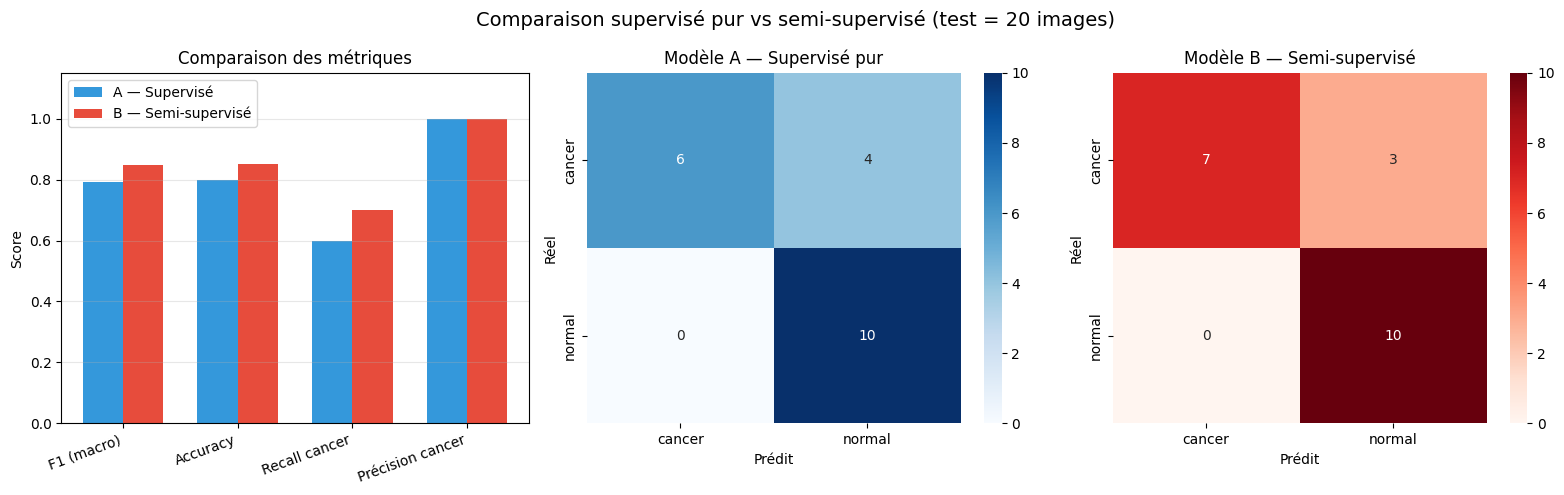

In [18]:
# Visualisations : barplot + matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Barplot des métriques
metrics_names = ['F1 (macro)', 'Accuracy', 'Recall cancer', 'Précision cancer']
values_A = [results_A['f1'], results_A['accuracy'], results_A['recall_cancer'], results_A['precision_cancer']]
values_B = [results_B['f1'], results_B['accuracy'], results_B['recall_cancer'], results_B['precision_cancer']]

x = np.arange(len(metrics_names))
width = 0.35
axes[0].bar(x - width/2, values_A, width, label='A — Supervisé', color='#3498db')
axes[0].bar(x + width/2, values_B, width, label='B — Semi-supervisé', color='#e74c3c')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des métriques')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)

# 2. Matrice de confusion — Modèle A
sns.heatmap(results_A['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Modèle A — Supervisé pur')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

# 3. Matrice de confusion — Modèle B
sns.heatmap(results_B['cm'], annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_title('Modèle B — Semi-supervisé')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')

plt.suptitle('Comparaison supervisé pur vs semi-supervisé (test = 20 images)', fontsize=14)
plt.tight_layout()
plt.show()

## Interprétation

### Résultat principal

| Modèle | F1 (macro) | Accuracy | Recall cancer | Précision cancer |
|--------|-----------|----------|---------------|-----------------|
| A — Supervisé pur | 0.79 | 0.80 | 0.60 | 1.00 |
| B — Semi-supervisé | **0.85** | **0.85** | **0.70** | 1.00 |
| **Δ (B − A)** | **+0.05** | **+0.05** | **+0.10** | 0 |

**L'approche semi-supervisée apporte un gain** : +5 points de F1 et +10 points de recall cancer. Le modèle B détecte 1 cancer supplémentaire sur 10 par rapport au modèle A, sans perdre en précision.

### Justification métier

Dans un contexte de détection de tumeurs (CurelyticsIA), un **Faux Négatif** (cancer prédit comme normal) est l'erreur la plus grave : cela signifie dire à un patient malade qu'il est sain. Le **Recall cancer** est donc la métrique à surveiller en priorité. Le modèle B semi-supervisé l'améliore de 60 % à 70 %, ce qui est cliniquement significatif même sur un jeu test petit.

### Analyse du checkpoint post-weak (bonus, évalué sur val)

Le modèle B après pré-entraînement sur les 1 406 weak labels seuls obtient un F1 de 0.56 et un recall cancer de 0.25 sur la validation. C'est médiocre — les pseudo-labels (ARI = 0.15) ne suffisent pas à créer un bon classifieur seuls. Mais ils fournissent une **initialisation orientée** que le fine-tuning sur les labels forts exploite ensuite avec succès.

### Limites de l'expérience

- **Jeu test de 20 images** : les métriques sont instables. Un seul Faux Négatif ou Faux Positif fait varier le recall de ±10 %. Les résultats ne doivent pas être surinterprétés.
- **Pseudo-labels de qualité modérée** (ARI = 0.15 à l'étape 3) : le pré-entraînement sur des labels bruités est une exploration, pas une garantie de gain.
- **Pas de data augmentation** : avec 64 images d'entraînement, l'overfitting est probable. En production, une augmentation (flips, rotations, crops) améliorerait la robustesse.
- **Résultats exploratoires** : ce notebook ne constitue pas une validation clinique. Il s'agit d'une preuve de concept pour évaluer l'intérêt d'une approche semi-supervisée.

## Recommandations — Passage à l'échelle

### La question de Clara

> Notre budget actuel pour la labellisation par IA est de 300 euros pour ce dataset.  
> Est-ce que ce passage te paraît faisable et si oui, sous quelles conditions ?  
> Budget de 5 000 euros pour 4 millions d'images à labelliser.

### Ma recommandation

**Réponse courte** : oui, le passage à l'échelle est faisable avec 5 000 €, sous certaines conditions.

#### Scénario 1 — Inférence avec le modèle entraîné

J'utilise le CNN semi-supervisé entraîné en étape 4 pour prédire les labels des 4 millions d'images :
- **Coût compute** : une instance GPU cloud (ex. AWS g4dn.xlarge ≈ 0,50-1 €/h) traitant ~100-200 images/seconde permettrait de traiter 4M d'images en ~6-11 heures, soit un coût d'infrastructure de **3-11 €**
- **Budget restant** : ~4 990 € pour la validation humaine

#### Scénario 2 — Active learning itératif (recommandé)

Plutôt que de labelliser toutes les images aveuglément :
1. **Inférer** les 4M d'images avec le modèle → obtenir des scores de confiance
2. **Cibler** les ~5-10 % d'images les plus incertaines → 200k-400k images
3. **Faire vérifier** ces images par des radiologues experts (coût typique : 0,02-0,10 €/image selon la plateforme)
4. **Réentraîner** le modèle avec ces nouveaux labels
5. **Itérer** jusqu'à convergence de la qualité

Avec 5 000 € et un coût de 0,05 €/image humaine, on peut labelliser **~100 000 images ciblées**, ce qui est bien plus efficace que de labelliser aléatoirement.

#### Conditions de faisabilité

- **Infrastructure cloud** : pipeline d'inférence batch, stockage des 4M d'images (~2 To si 500 Ko/image)
- **Plateforme de labellisation** : Label Studio (open source) ou Amazon SageMaker Ground Truth
- **Monitoring qualité** : validation humaine sur un échantillon aléatoire à chaque itération
- **Protocole médical** : les prédictions du modèle ne remplacent pas un diagnostic — elles servent d'aide au tri

#### Ce que le budget ne permet PAS

- Labelliser manuellement les 4M d'images (coût > 200 000 €)
- Entraîner un modèle from scratch sur un cluster GPU (coût > 10 000 €)
- Certifier le modèle comme dispositif médical (coût réglementaire >> 5 000 €)

## Definition of done — Validation

- [x] Split stratifié train/val/test (64/16/20) sur le jeu fort
- [x] K-Means re-calculé sans les 20 images test
- [x] Mapping cluster → classe refait sur le train uniquement
- [x] Weak labels re-générés proprement
- [x] Modèle A entraîné sur 64, val 16, évalué sur 20
- [x] Modèle B (weak → strong) entraîné et évalué sur le même test
- [x] Même architecture, mêmes transforms, même protocole pour A et B
- [x] F1, accuracy, recall cancer, matrice de confusion
- [x] Comparaison tabulaire + visuelle
- [x] Recommandations passage à l'échelle
- [x] `random_state=42` partout